# 00 · Smoke notebook — multi-agent coupling layer

Primary entry point for the simulation. Each cell exercises one piece of the
predicted dynamics from the paper (`paper/sections/04_model.tex` §4).

The model now carries a per-agent salience prior `C_i ∈ ℝ^R` over R named
features φ_r (default R = 4); each step samples one situation σ_t (= a
feature index), agents act on `σ(C_i[σ_t])`, the env reveals `s_star[σ_t]`,
and the per-norm closed-form `C`-update fires per feature. λ is per-norm
(`(N, R)`).

We run smoke checks at a small `n_agents=30` so each cell stays fast; the
phase-space notebook scales up to N=300 on a Barabási–Albert graph for
cluster visualisation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    build, ModelConfig, EnvConfig, EvolutionRegime, History,
)

sns.set_theme(context='notebook', style='whitegrid')

## Cell 1 — smoke build

In [2]:
env, pop = build(
    ModelConfig(n_agents=30, n_features=4, seed=0),
    EnvConfig(n_agents=30, n_features=4, seed=0),
)
pop

C:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:60: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


Population(N=30, R=4, edges=56, d_mean=0.698, lambda_mean=1.000, gamma_mean=0.268, C_std=0.000)

## Cell 2 — stationary regime, λ = 0 (Bayes-optimal limit)

Mean payoff should rise monotonically toward 1.0 within ~30 steps.

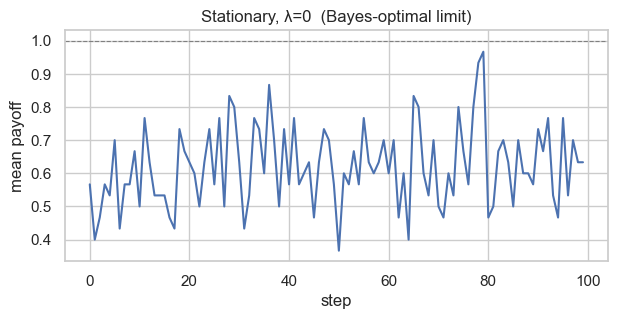

In [3]:
env, pop = build(
    ModelConfig(n_agents=30, n_features=4,
                lambda_dist=('constant', {'value': 0.0}), seed=0),
    EnvConfig(n_agents=30, n_features=4, seed=0),
)
h = History()
for _ in range(100):
    pop, out = pop.step(env)
    h.append(out)

arrs = h.as_arrays()
mean_payoff = arrs['payoffs'].mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(mean_payoff, lw=1.5)
ax.axhline(1.0, ls='--', c='grey', lw=0.8)
ax.set(xlabel='step', ylabel='mean payoff', title='Stationary, λ=0  (Bayes-optimal limit)')
plt.show()

## Cell 3 — discrete shift, λ large (lag under shock)

Population converges before $t^*=50$, then `s*` flips. With high λ, recovery
should be visibly slower than the initial convergence.

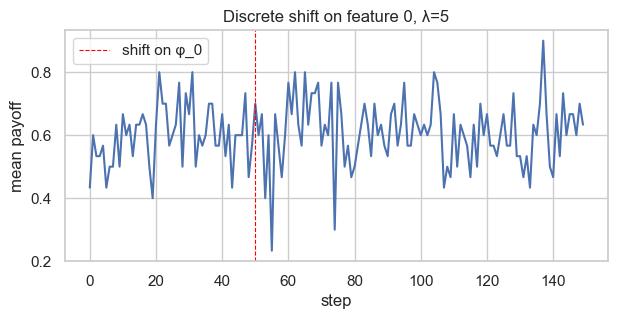

In [4]:
shift_t = 50
env, pop = build(
    ModelConfig(n_agents=30, n_features=4,
                lambda_dist=('constant', {'value': 5.0}), seed=0),
    EnvConfig(
        n_agents=30, n_features=4,
        regime=EvolutionRegime.DISCRETE_SHIFT,
        shift_time=shift_t, shift_features=(0,), seed=2,
    ),
)
h = History()
for _ in range(150):
    pop, out = pop.step(env)
    h.append(out)

arrs = h.as_arrays()
mean_payoff = arrs['payoffs'].mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(mean_payoff, lw=1.5)
ax.axvline(shift_t, ls='--', c='red', lw=0.8, label='shift on φ_0')
ax.set(xlabel='step', ylabel='mean payoff', title='Discrete shift on feature 0, λ=5')
ax.legend()
plt.show()

## Cell 4 — slow drift, low vs high λ (hysteresis preview)

Same env trajectory, two λ values. The high-λ run should track the drifting
$s^*$ more sluggishly. (Headline forward/reverse loops live in a dedicated
experiment notebook; this cell just shows the qualitative gap.)

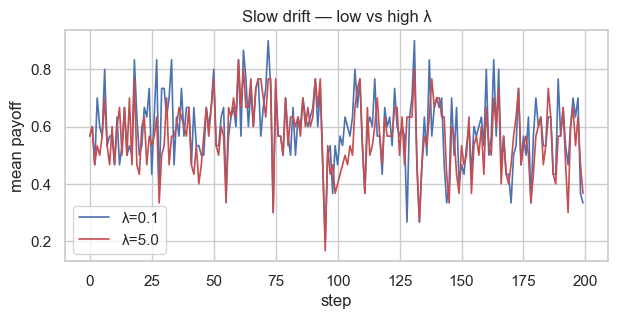

In [5]:
T = 200
fig, ax = plt.subplots(figsize=(7, 3))
for lam, color in [(0.1, 'C0'), (5.0, 'C3')]:
    env, pop = build(
        ModelConfig(n_agents=30, n_features=4,
                    lambda_dist=('constant', {'value': lam}), seed=0),
        EnvConfig(
            n_agents=30, n_features=4,
            regime=EvolutionRegime.SLOW_DRIFT,
            drift_step_prob=0.05, seed=7,
        ),
    )
    h = History()
    for _ in range(T):
        pop, out = pop.step(env)
        h.append(out)
    arrs = h.as_arrays()
    ax.plot(arrs['payoffs'].mean(axis=1), lw=1.2, color=color, label=f'λ={lam}')
ax.set(xlabel='step', ylabel='mean payoff', title='Slow drift — low vs high λ')
ax.legend()
plt.show()

## Cell 5 — γ heatmap

Trust matrix after a stationary rollout. Should be spatially structured
(masked by adjacency, modulated by per-neighbour evidence) — not all-zero,
not uniform.

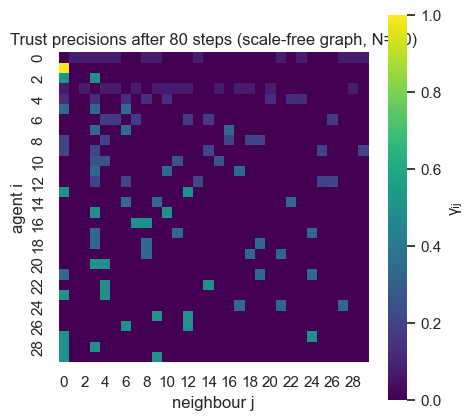

In [6]:
env, pop = build(
    ModelConfig(n_agents=30, n_features=4,
                lambda_dist=('constant', {'value': 1.0}), seed=0),
    EnvConfig(n_agents=30, n_features=4, seed=0),
)
for _ in range(80):
    pop, _ = pop.step(env)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(np.asarray(pop.gamma), cmap='viridis', square=True,
            cbar_kws={'label': 'γᵢⱼ'}, ax=ax)
ax.set(xlabel='neighbour j', ylabel='agent i',
       title='Trust precisions after 80 steps (scale-free graph, N=30)')
plt.show()